# Credit Scoring — Polish Companies Bankruptcy
**Objetivo:** Predecir incumplimiento de pago en empresas usando datos financieros.  
**Dataset:** Polish Companies Bankruptcy (UCI ML Repository, id=365)  
**Tracking:** MLflow local  
**Explicabilidad:** SHAP  

## 0. Instalación de dependencias

In [ ]:
# Ejecutar solo la primera vez
# !pip install ucimlrepo xgboost shap mlflow imbalanced-learn matplotlib seaborn

In [ ]:
#!pip install ucimlrepo xgboost shap mlflow imbalanced-learn matplotlib seaborn

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE

import xgboost as xgb
import shap
import mlflow
import mlflow.xgboost

print(f"XGBoost: {xgb.__version__}")
print(f"MLflow:  {mlflow.__version__}")
print(f"SHAP:    {shap.__version__}")

XGBoost: 3.2.0
MLflow:  3.11.1
SHAP:    0.51.0


## 2. Carga del Dataset

In [2]:
polish_companies_bankruptcy = fetch_ucirepo(id=365)

X = polish_companies_bankruptcy.data.features
y = polish_companies_bankruptcy.data.targets

print("=== METADATA ===")
print(polish_companies_bankruptcy.metadata)
print("\n=== VARIABLES ===")
print(polish_companies_bankruptcy.variables)

=== METADATA ===
{'uci_id': 365, 'name': 'Polish Companies Bankruptcy', 'repository_url': 'https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data', 'data_url': 'https://archive.ics.uci.edu/static/public/365/data.csv', 'abstract': 'The dataset is about bankruptcy prediction of Polish companies.The bankrupt companies were analyzed in the period 2000-2012, while the still operating companies were evaluated from 2007 to 2013.', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 10503, 'num_features': 65, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2016, 'last_updated': 'Sat Mar 09 2024', 'dataset_doi': '10.24432/C5F600', 'creators': ['Sebastian Tomczak'], 'intro_paper': {'ID': 417, 'type': 'NATIVE', 'title': 'Ensemble boosted trees with synthetic features generation in application to ban

In [35]:
X.head()

,year,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A55,A56,A57,A58,A59,A60,A61,A62,A63,A64
0,1,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,...,348690.0,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277
1,1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,...,2304.6,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870
2,1,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,...,6332.7,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078
3,1,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,...,20545.0,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497
4,1,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,...,3186.6,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980


In [3]:
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"\nColumnas: {X.columns.tolist()}")
print(f"\nTarget único: {y.iloc[:, 0].unique()}")

Shape X: (43405, 65)
Shape y: (43405, 1)

Columnas: ['year', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61', 'A62', 'A63', 'A64']

Target único: [0 1]


## 3. Exploración de Datos (EDA)

Distribución del target:
class
0    41314
1     2091
Name: count, dtype: int64

Desbalance: 19.8:1 (no quiebra : quiebra)


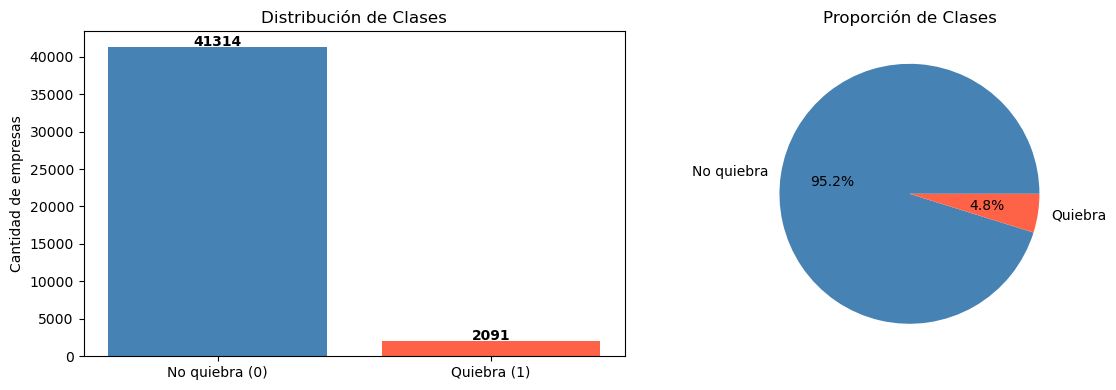

In [4]:
# Target: distribución de clases
target_col = y.columns[0]
y_series = y[target_col]

class_counts = y_series.value_counts()
print("Distribución del target:")
print(class_counts)
print(f"\nDesbalance: {class_counts[0] / class_counts[1]:.1f}:1 (no quiebra : quiebra)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['No quiebra (0)', 'Quiebra (1)'], class_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Distribución de Clases')
axes[0].set_ylabel('Cantidad de empresas')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=['No quiebra', 'Quiebra'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1].set_title('Proporción de Clases')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

Columnas con más del 30% de nulos:
A37    43.736897
dtype: float64

Total columnas con nulos: 64 de 65


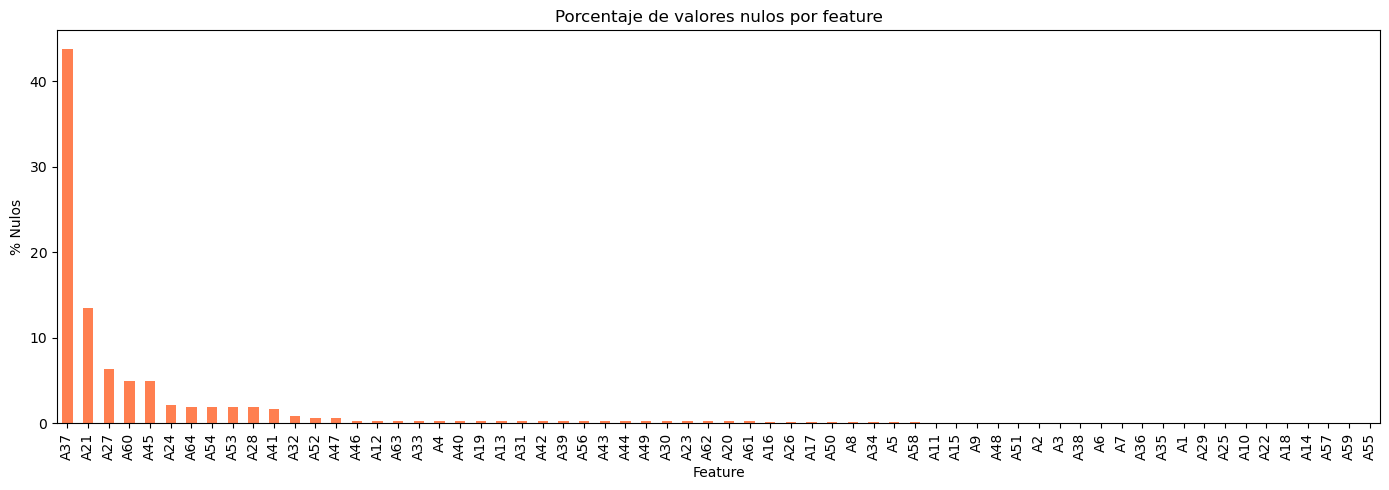

In [5]:
# Valores nulos por columna
missing = X.isnull().sum()
missing_pct = (missing / len(X) * 100).sort_values(ascending=False)

print(f"Columnas con más del 30% de nulos:")
print(missing_pct[missing_pct > 30])
print(f"\nTotal columnas con nulos: {(missing > 0).sum()} de {X.shape[1]}")

plt.figure(figsize=(14, 5))
missing_pct[missing_pct > 0].plot(kind='bar', color='coral')
plt.title('Porcentaje de valores nulos por feature')
plt.ylabel('% Nulos')
plt.xlabel('Feature')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=100, bbox_inches='tight')
plt.show()

In [6]:
# Estadísticas descriptivas
print("Estadísticas descriptivas (primeras 10 features):")
X.describe().T.head(10)

Estadísticas descriptivas (primeras 10 features):


,count,mean,std,min,25%,50%,75%,max
year,43405.0,2.939753,1.283975,1.000000e+00,2.000000,3.000000,4.000000,5.000
A1,43397.0,0.035160,2.994109,-4.638900e+02,0.003429,0.049660,0.129580,94.280
A2,43397.0,0.590212,5.842748,-4.308700e+02,0.268980,0.471900,0.688320,480.960
A3,43397.0,0.114431,5.439429,-4.799600e+02,0.021521,0.196610,0.403390,28.336
A4,43271.0,6.314702,295.434425,-4.031100e-01,1.049500,1.569800,2.787450,53433.000
A5,43316.0,-385.347987,61227.968306,-1.190000e+07,-49.080000,-1.034500,50.634250,1250100.000
A6,43397.0,-0.056107,7.201326,-5.084100e+02,0.000000,0.000000,0.089446,543.250
A7,43397.0,0.093478,5.713075,-5.174800e+02,0.005776,0.059634,0.150880,649.230
A8,43311.0,12.640779,505.894281,-1.414100e+02,0.430275,1.070400,2.615700,53432.000
A9,43396.0,2.652166,62.932732,-3.496000e+00,1.018500,1.195350,2.062500,9742.300


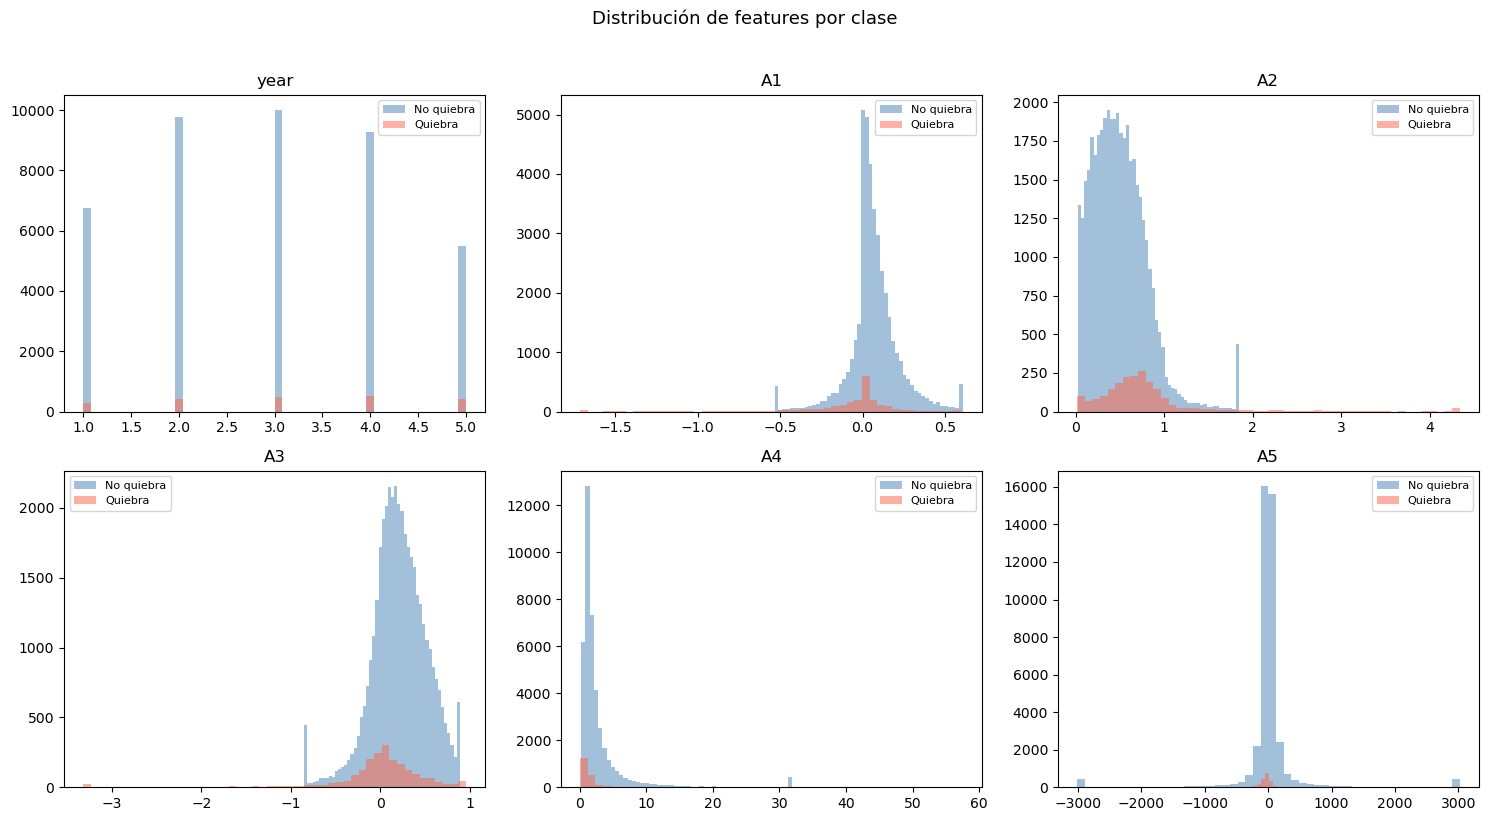

In [7]:
# Distribución de features clave (primeras 6)
features_plot = X.columns[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

df_temp = X[features_plot].copy()
df_temp['target'] = y_series.values

for i, col in enumerate(features_plot):
    for label, color in zip([0, 1], ['steelblue', 'tomato']):
        data = df_temp[df_temp['target'] == label][col].dropna()
        # Clip extremos para visualización
        q01, q99 = data.quantile(0.01), data.quantile(0.99)
        data = data.clip(q01, q99)
        axes[i].hist(data, bins=50, alpha=0.5, color=color,
                     label='No quiebra' if label == 0 else 'Quiebra')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de features por clase', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Preprocesamiento

In [8]:
# Eliminar columnas con más del 50% de nulos
threshold = 0.50
cols_to_drop = missing_pct[missing_pct > threshold * 100].index.tolist()
print(f"Columnas eliminadas (>{threshold*100}% nulos): {len(cols_to_drop)}")
print(cols_to_drop)

X_clean = X.drop(columns=cols_to_drop)
print(f"\nShape después de eliminar columnas: {X_clean.shape}")

Columnas eliminadas (>50.0% nulos): 0
[]

Shape después de eliminar columnas: (43405, 65)


In [9]:
# Imputar nulos restantes con la mediana
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_clean),
    columns=X_clean.columns
)

print(f"Nulos después de imputar: {X_imputed.isnull().sum().sum()}")

Nulos después de imputar: 0


In [10]:
# Clip de outliers extremos (percentil 1 y 99)
for col in X_imputed.columns:
    q01 = X_imputed[col].quantile(0.01)
    q99 = X_imputed[col].quantile(0.99)
    X_imputed[col] = X_imputed[col].clip(q01, q99)

print("Outliers clipeados en percentiles 1-99")

Outliers clipeados en percentiles 1-99


In [11]:
# Train/Test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y_series,
    test_size=0.20,
    random_state=42,
    stratify=y_series
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train positivos: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Test  positivos: {y_test.sum()}  ({y_test.mean()*100:.2f}%)")

Train: (34724, 65) | Test: (8681, 65)
Train positivos: 1673 (4.82%)
Test  positivos: 418  (4.82%)


In [12]:
# Aplicar SMOTE para balancear el training set
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Train balanceado: {X_train_bal.shape}")
print(f"Distribución post-SMOTE: {pd.Series(y_train_bal).value_counts().to_dict()}")

Train balanceado: (66102, 65)
Distribución post-SMOTE: {0: 33051, 1: 33051}


## 5. Entrenamiento del Modelo con MLflow

In [13]:
# Configurar MLflow
mlflow.set_tracking_uri("sqlite:///mlflow_credit.db")
mlflow.set_experiment("credit-scoring-polish")

print("MLflow configurado. UI disponible ejecutando: mlflow ui --backend-store-uri sqlite:///mlflow_credit.db")

2026/04/26 16:43:26 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/26 16:43:26 INFO mlflow.store.db.utils: Updating database tables
2026/04/26 16:43:28 INFO mlflow.tracking.fluent: Experiment with name 'credit-scoring-polish' does not exist. Creating a new experiment.


MLflow configurado. UI disponible ejecutando: mlflow ui --backend-store-uri sqlite:///mlflow_credit.db


In [14]:
# Parámetros del modelo
params = {
    "n_estimators":     300,
    "max_depth":        5,
    "learning_rate":    0.05,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "gamma":            0.1,
    "scale_pos_weight": 1,       # 1 porque ya balanceamos con SMOTE
    "eval_metric":      "auc",
    "use_label_encoder": False,
    "random_state":     42,
    "n_jobs":           -1
}

with mlflow.start_run(run_name="xgboost_smote_v1"):

    # Loguear parámetros
    mlflow.log_params(params)
    mlflow.log_param("imputer_strategy", "median")
    mlflow.log_param("outlier_clip", "p1-p99")
    mlflow.log_param("balancing", "SMOTE")
    mlflow.log_param("test_size", 0.20)
    mlflow.log_param("features_used", X_imputed.shape[1])

    # Entrenar
    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train_bal, y_train_bal,
        eval_set=[(X_test, y_test)],
        verbose=50
    )

    # Predicciones
    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Métricas
    roc_auc   = roc_auc_score(y_test, y_pred_proba)
    avg_prec  = average_precision_score(y_test, y_pred_proba)
    report    = classification_report(y_test, y_pred, output_dict=True)

    mlflow.log_metric("roc_auc",         roc_auc)
    mlflow.log_metric("avg_precision",   avg_prec)
    mlflow.log_metric("precision_class1", report['1']['precision'])
    mlflow.log_metric("recall_class1",    report['1']['recall'])
    mlflow.log_metric("f1_class1",        report['1']['f1-score'])

    # Guardar modelo
    mlflow.xgboost.log_model(model, "xgboost_model")

    # Guardar artefactos
    mlflow.log_artifact("class_distribution.png")
    mlflow.log_artifact("missing_values.png")
    mlflow.log_artifact("feature_distributions.png")

    run_id = mlflow.active_run().info.run_id

print(f"\nRun ID: {run_id}")
print(f"ROC-AUC:       {roc_auc:.4f}")
print(f"Avg Precision: {avg_prec:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['No quiebra', 'Quiebra'])}")

[0]	validation_0-auc:0.76152
[50]	validation_0-auc:0.88734
[100]	validation_0-auc:0.90560
[150]	validation_0-auc:0.91965
[200]	validation_0-auc:0.93403
[250]	validation_0-auc:0.94253
[299]	validation_0-auc:0.94907


2026/04/26 16:43:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Run ID: 94d1e8260c084aeb84b1fa4e99d99174
ROC-AUC:       0.9491
Avg Precision: 0.6824

              precision    recall  f1-score   support

  No quiebra       0.98      0.99      0.98      8263
     Quiebra       0.71      0.55      0.62       418

    accuracy                           0.97      8681
   macro avg       0.84      0.77      0.80      8681
weighted avg       0.96      0.97      0.97      8681



## 6. Evaluación Visual

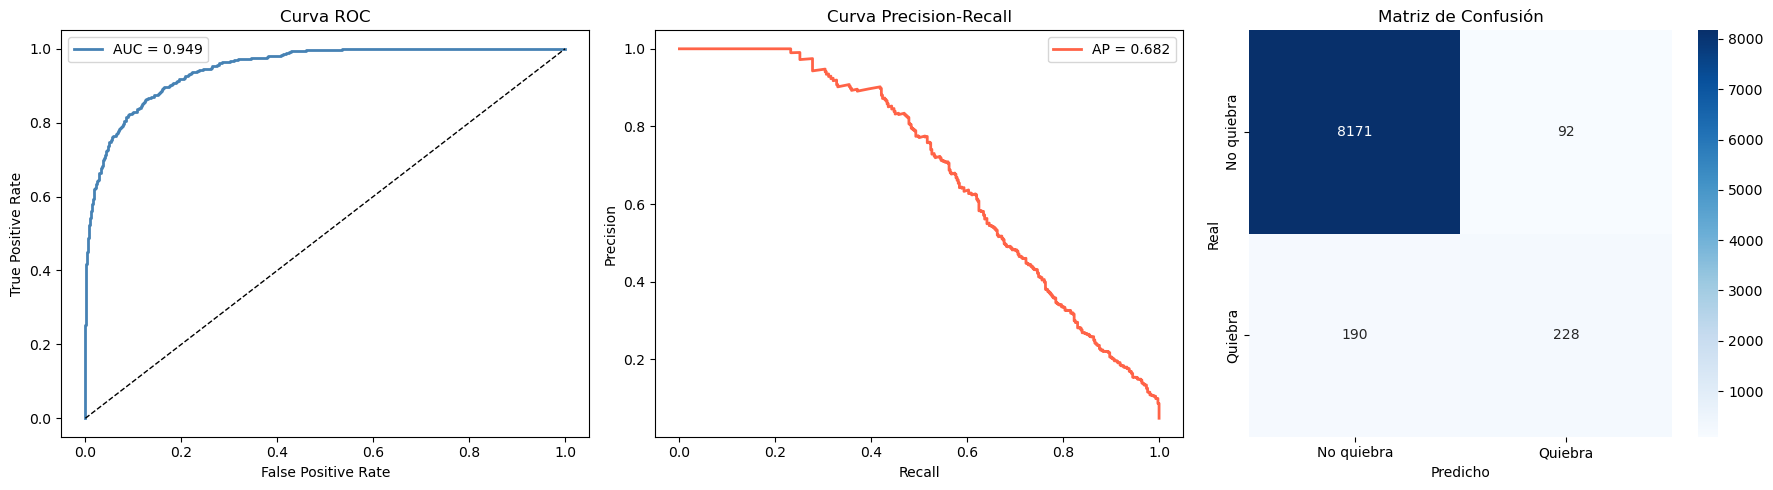

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC')
axes[0].legend()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(recall, precision, color='tomato', lw=2, label=f'AP = {avg_prec:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['No quiebra', 'Quiebra'],
            yticklabels=['No quiebra', 'Quiebra'])
axes[2].set_title('Matriz de Confusión')
axes[2].set_ylabel('Real')
axes[2].set_xlabel('Predicho')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=100, bbox_inches='tight')
plt.show()

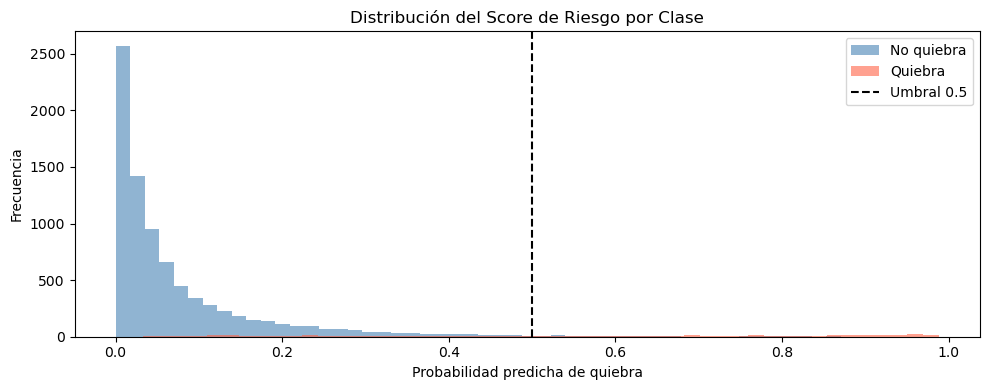

In [16]:
# Distribución del score de probabilidad
plt.figure(figsize=(10, 4))
plt.hist(y_pred_proba[y_test == 0], bins=50, alpha=0.6, color='steelblue', label='No quiebra')
plt.hist(y_pred_proba[y_test == 1], bins=50, alpha=0.6, color='tomato', label='Quiebra')
plt.axvline(0.5, color='black', linestyle='--', label='Umbral 0.5')
plt.xlabel('Probabilidad predicha de quiebra')
plt.ylabel('Frecuencia')
plt.title('Distribución del Score de Riesgo por Clase')
plt.legend()
plt.tight_layout()
plt.savefig('score_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Explicabilidad con SHAP

In [17]:
# Calcular SHAP values (usando muestra para velocidad)
sample_size = min(500, len(X_test))
X_test_sample = X_test.sample(n=sample_size, random_state=42)

explainer    = shap.TreeExplainer(model)
shap_values  = explainer.shap_values(X_test_sample)

print(f"SHAP values calculados para {sample_size} empresas")
print(f"Shape SHAP values: {shap_values.shape}")

SHAP values calculados para 500 empresas
Shape SHAP values: (500, 65)


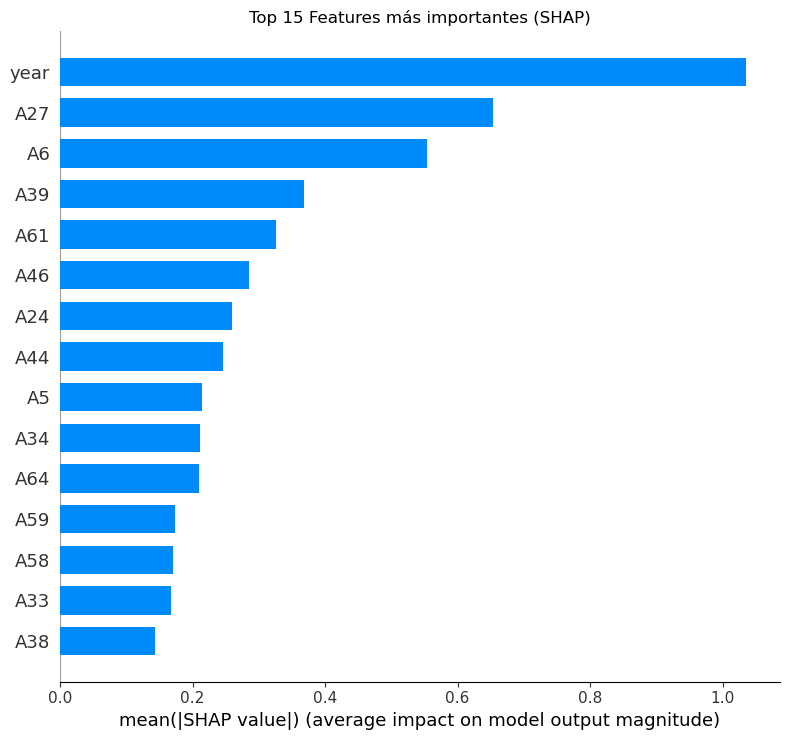

In [18]:
# Top features globales — importancia promedio
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar",
                  max_display=15, show=False)
plt.title('Top 15 Features más importantes (SHAP)')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=100, bbox_inches='tight')
plt.show()

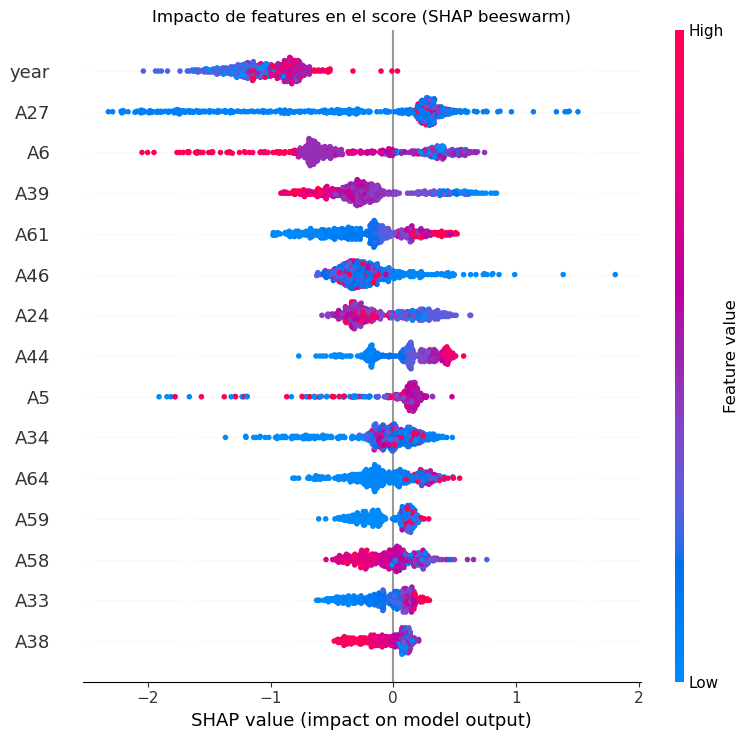

In [19]:
# SHAP beeswarm — dirección del impacto
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, max_display=15, show=False)
plt.title('Impacto de features en el score (SHAP beeswarm)')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Análisis de una Empresa Individual

In [20]:
def analizar_empresa(index, X_data, y_data, modelo, explainer):
    """
    Analiza el riesgo crediticio de una empresa y devuelve
    score + drivers principales (SHAP).
    """
    empresa = X_data.iloc[[index]]
    real    = y_data.iloc[index]

    proba  = modelo.predict_proba(empresa)[0][1]
    shap_v = explainer.shap_values(empresa)[0]

    # Top 5 drivers (positivos = aumentan riesgo, negativos = reducen riesgo)
    feature_impact = pd.Series(shap_v, index=empresa.columns)
    top_drivers    = feature_impact.abs().sort_values(ascending=False).head(5)
    drivers_detail = feature_impact[top_drivers.index]

    # Clasificación del riesgo
    if proba < 0.2:
        riesgo = "BAJO"
    elif proba < 0.5:
        riesgo = "MEDIO"
    elif proba < 0.75:
        riesgo = "ALTO"
    else:
        riesgo = "MUY ALTO"

    print(f"{'='*55}")
    print(f" ANÁLISIS DE RIESGO CREDITICIO — Empresa #{index}")
    print(f"{'='*55}")
    print(f" Score de quiebra : {proba*100:.1f}%")
    print(f" Nivel de riesgo  : {riesgo}")
    print(f" Valor real       : {'Quiebra' if real == 1 else 'No quiebra'}")
    print(f"{'='*55}")
    print(" TOP 5 DRIVERS DEL SCORE:")
    for feat, impact in drivers_detail.items():
        valor   = empresa[feat].values[0]
        signo   = "↑ AUMENTA RIESGO" if impact > 0 else "↓ REDUCE RIESGO"
        print(f"   {feat:15s} | valor={valor:8.3f} | SHAP={impact:+.4f} | {signo}")
    print(f"{'='*55}")

    return proba, drivers_detail


# Analizar una empresa del test set
# Buscar una empresa que quebró para el ejemplo
quiebras_idx = y_test[y_test == 1].index
empresa_ejemplo = X_test.index.get_loc(quiebras_idx[0])

proba, drivers = analizar_empresa(
    index=empresa_ejemplo,
    X_data=X_test,
    y_data=y_test.reset_index(drop=True),
    modelo=model,
    explainer=explainer
)

 ANÁLISIS DE RIESGO CREDITICIO — Empresa #28
 Score de quiebra : 71.6%
 Nivel de riesgo  : ALTO
 Valor real       : Quiebra
 TOP 5 DRIVERS DEL SCORE:
   year            | valor=   3.000 | SHAP=-1.0582 | ↓ REDUCE RIESGO
   A39             | valor=  -0.086 | SHAP=+0.7756 | ↑ AUMENTA RIESGO
   A61             | valor=   1.943 | SHAP=-0.6302 | ↓ REDUCE RIESGO
   A56             | valor=   0.652 | SHAP=+0.5840 | ↑ AUMENTA RIESGO
   A37             | valor=   0.327 | SHAP=-0.5779 | ↓ REDUCE RIESGO


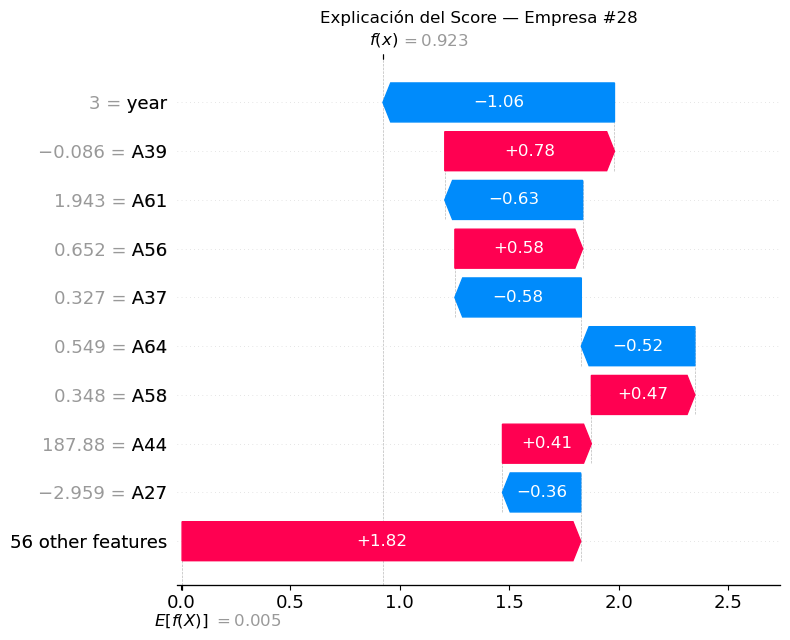

In [21]:
# Waterfall plot — explicación visual de una empresa
empresa_shap = shap.Explanation(
    values=explainer.shap_values(X_test.iloc[[empresa_ejemplo]])[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[empresa_ejemplo].values,
    feature_names=X_test.columns.tolist()
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(empresa_shap, max_display=10, show=False)
plt.title(f'Explicación del Score — Empresa #{empresa_ejemplo}')
plt.tight_layout()
plt.savefig('shap_waterfall_empresa.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. Loguear artefactos SHAP en MLflow

In [22]:
# Agregar artefactos SHAP al run anterior
with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact('shap_importance.png')
    mlflow.log_artifact('shap_beeswarm.png')
    mlflow.log_artifact('shap_waterfall_empresa.png')
    mlflow.log_artifact('model_evaluation.png')
    mlflow.log_artifact('score_distribution.png')

    # Loguear top features
    feature_importance = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=X_test_sample.columns
    ).sort_values(ascending=False)

    for i, (feat, imp) in enumerate(feature_importance.head(10).items()):
        mlflow.log_metric(f"shap_importance_top{i+1:02d}_{feat}", imp)

print("Artefactos SHAP logueados en MLflow")
print(f"\nPara ver la UI ejecuta en terminal:")
print("  mlflow ui --workers 1 --backend-store-uri sqlite:///mlflow_credit.db")
print("  Luego abre: http://localhost:5000")

Artefactos SHAP logueados en MLflow

Para ver la UI ejecuta en terminal:
  mlflow ui --workers 1 --backend-store-uri sqlite:///mlflow_credit.db
  Luego abre: http://localhost:5000


## 10. Resumen y Próximos Pasos

### Lo que hicimos:
- Cargamos el dataset Polish Companies Bankruptcy (UCI)
- EDA: distribución de clases, valores nulos, distribución de features
- Preprocesamiento: eliminación de columnas con >50% nulos, imputación por mediana, clip de outliers
- Balanceo de clases con SMOTE
- Entrenamiento de XGBoost con tracking completo en MLflow
- Evaluación: ROC-AUC, Precision-Recall, Confusion Matrix
- Explicabilidad global (SHAP summary) y local (waterfall por empresa)

### Próximos pasos:
1. **Optimización de hiperparámetros** — Optuna o GridSearchCV con MLflow
2. **Umbral óptimo** — ajustar threshold según costo de FP vs FN
3. **Agente IA** — integrar Claude API para explicaciones narrativas usando SHAP drivers
4. **Web local** — desplegar en Streamlit con input de empresa y reporte de score

## 11. Registro del Modelo en MLflow Model Registry

In [23]:
from mlflow.tracking import MlflowClient

MODEL_NAME = 'credit-scoring-polish'

model_uri = f'runs:/{run_id}/xgboost_model'
registered = mlflow.register_model(model_uri=model_uri, name=MODEL_NAME)

print(f'Modelo registrado: {registered.name}')
print(f'Version:           {registered.version}')
print(f'Run ID:            {registered.run_id}')


Successfully registered model 'credit-scoring-polish'.
2026/04/26 16:52:20 WARNING mlflow.tracking._model_registry.fluent: Run with id 94d1e8260c084aeb84b1fa4e99d99174 has no artifacts at artifact path 'xgboost_model', registering model based on models:/m-f411826dcf8845efaec9761652f78696 instead


Modelo registrado: credit-scoring-polish
Version:           1
Run ID:            94d1e8260c084aeb84b1fa4e99d99174


Created version '1' of model 'credit-scoring-polish'.


In [24]:
# Promover a alias production
client  = MlflowClient(tracking_uri='sqlite:///mlflow_credit.db')
version = registered.version

client.set_registered_model_alias(
    name=MODEL_NAME,
    alias='production_80',
    version=version
)

print(f'Modelo v{version} marcado como alias=production_80')
print(f'URI para servir: models:/{MODEL_NAME}@production_80')


Modelo v1 marcado como alias=production_80
URI para servir: models:/credit-scoring-polish@production_80


## 12. Levantar el Modelo como API REST (MLflow Serving)

### Paso 1 — Levantar la API en una terminal nueva

Ejecuta este comando en PowerShell (**no en el notebook**):

```bash
mlflow models serve --model-uri "models:/credit-scoring-polish@production_80" --port 5002 --workers 1 --env-manager local --no-conda
```

> `--env-manager local` usa el Python actual (Anaconda) sin crear un entorno nuevo.  
> `--no-conda` evita errores de entorno en Windows.


FIX:
```bash
cd "C:\Users\TITAN\OneDrive\SCRIPTS\PY"

Línea 1:  $env:MLFLOW_TRACKING_URI = "sqlite:///C:/Users/TITAN/OneDrive/SCRIPTS/PY/mlflow_credit.db"
Línea 2:    mlflow models serve --model-uri "models:/credit-scoring-polish@production_80" --port 5002 --workers 1 --env-manager local --no-conda
```

### Paso 2 — Probar desde el notebook (celda siguiente)

In [25]:
import requests
import json as json_lib

API_URL = 'http://localhost:5002/invocations'

empresa_test = X_test.iloc[[0]]

payload = {
    'dataframe_split': {
        'columns': empresa_test.columns.tolist(),
        'data':    empresa_test.values.tolist()
    }
}

response = requests.post(
    API_URL,
    headers={'Content-Type': 'application/json'},
    data=json_lib.dumps(payload)
)

print(f'Status: {response.status_code}')
print(f'Respuesta: {response.text}')


Status: 200
Respuesta: {"predictions": [0]}


In [26]:
def score_empresa_via_api(features_dict: dict, url: str = API_URL) -> dict:
    '''
    Envia datos de una empresa a la API MLflow.
    features_dict: {A1: valor, A2: valor, ...}
    Retorna clase predicha y nivel de riesgo.
    '''
    df_input = pd.DataFrame([features_dict])
    for col in X_test.columns:
        if col not in df_input.columns:
            df_input[col] = 0.0
    df_input = df_input[X_test.columns]

    payload = {
        'dataframe_split': {
            'columns': df_input.columns.tolist(),
            'data':    df_input.values.tolist()
        }
    }
    resp = requests.post(url, headers={'Content-Type': 'application/json'},
                         data=json_lib.dumps(payload))
    prediccion = resp.json()['predictions'][0]
    return {
        'clase_predicha': int(prediccion),
        'riesgo':         'Quiebra' if prediccion == 1 else 'No quiebra',
        'status_api':     resp.status_code
    }


empresa_dict = X_test.iloc[0].to_dict()
resultado = score_empresa_via_api(empresa_dict)
print(f'Clase predicha : {resultado["clase_predicha"]}')
print(f'Nivel de riesgo: {resultado["riesgo"]}')
print(f'HTTP status    : {resultado["status_api"]}')


Clase predicha : 0
Nivel de riesgo: No quiebra
HTTP status    : 200


## Resumen — Comandos para levantar todo

```bash
# Terminal 1 — MLflow UI
mlflow ui --workers 1 --port 5000 --backend-store-uri sqlite:///mlflow_credit.db

# Terminal 2 — API del modelo
mlflow models serve --model-uri "models:/credit-scoring-polish@production" --port 5002 --workers 1 --env-manager local --no-conda
```

```
Notebook (entrenamiento)
       ↓
 MLflow Tracking (mlflow_credit.db)
       ↓
 Model Registry → alias: production
       ↓
 API REST → http://localhost:5002/invocations
       ↓
 Agente IA / Streamlit (próximo paso)
```

## 13. Agente de Explicacion con Ollama (Gemma local)

In [29]:
#!pip install ollama

In [30]:
# Instalar si no esta instalado
# !pip install ollama

import ollama

try:
    modelos = ollama.list()
    print('Ollama conectado. Modelos disponibles:')
    for m in modelos.get('models', []):
        print(f'  - {m["model"]}')
except Exception as e:
    print(f'Error conectando Ollama: {e}')
    print('Ejecuta en terminal: ollama serve')


Ollama conectado. Modelos disponibles:
  - gemma4:e2b


In [31]:
OLLAMA_MODEL   = 'gemma4:e2b'
MLFLOW_API_URL = 'http://localhost:5002/invocations'

# Descripcion de features en espanol
FEATURE_DESC = {
    'year': 'horizonte de pronostico (anos antes de quiebra)',
    'A1':  'utilidad neta / activos totales',
    'A2':  'pasivos totales / activos totales',
    'A3':  'capital de trabajo / activos totales',
    'A4':  'activos corrientes / pasivos corrientes (liquidez)',
    'A5':  'ciclo de caja en dias',
    'A6':  'utilidades retenidas / activos totales',
    'A7':  'EBIT / activos totales',
    'A8':  'patrimonio contable / pasivos totales',
    'A9':  'ventas / activos totales (rotacion)',
    'A10': 'patrimonio / activos totales',
    'A17': 'activos totales / pasivos totales',
    'A18': 'utilidad bruta / activos totales',
    'A19': 'margen bruto (utilidad bruta / ventas)',
    'A21': 'crecimiento de ventas',
    'A22': 'utilidad operativa / activos totales',
    'A23': 'utilidad neta / ventas (margen neto)',
    'A26': '(utilidad neta + depreciacion) / pasivos totales',
    'A27': 'utilidad operativa / gastos financieros',
    'A29': 'logaritmo de activos totales (tamano empresa)',
    'A35': 'utilidad en ventas / activos totales',
    'A36': 'ventas totales / activos totales',
    'A39': 'margen de utilidad en ventas',
    'A40': 'prueba acida (sin inventarios)',
    'A42': 'margen operativo',
    'A44': 'dias de cobro (cuentas por cobrar)',
    'A48': 'EBITDA / activos totales',
    'A49': 'EBITDA / ventas',
    'A50': 'activos corrientes / pasivos totales',
    'A51': 'pasivos corrientes / activos totales',
    'A56': 'margen bruto (ventas - costos) / ventas',
    'A58': 'costos totales / ventas totales',
    'A61': 'rotacion de cuentas por cobrar',
    'A63': 'ventas / pasivos corrientes',
    'A64': 'ventas / activos fijos',
}

print(f'Modelo configurado: {OLLAMA_MODEL}')


Modelo configurado: gemma4:e2b


In [32]:
def obtener_drivers(empresa_df, explainer, top_n=6):
    shap_vals = explainer.shap_values(empresa_df)[0]
    impacto   = pd.Series(shap_vals, index=empresa_df.columns)
    top       = impacto.abs().sort_values(ascending=False).head(top_n)
    return {
        feat: {
            'valor':      round(float(empresa_df[feat].values[0]), 4),
            'shap':       round(float(impacto[feat]), 4),
            'descripcion': FEATURE_DESC.get(feat, feat),
            'sube_riesgo': impacto[feat] > 0
        }
        for feat in top.index
    }


def clasificar_riesgo(proba):
    if proba < 0.20: return 'BAJO'
    if proba < 0.50: return 'MEDIO'
    if proba < 0.75: return 'ALTO'
    return 'MUY ALTO'


def construir_prompt(score_pct, nivel, drivers, empresa_id):
    lineas = []
    for feat, d in drivers.items():
        efecto = 'AUMENTA el riesgo' if d['sube_riesgo'] else 'REDUCE el riesgo'
        lineas.append(f'  - {feat} ({d["descripcion"]}): valor={d["valor"]:.4f} -> {efecto}')
    return (
        f'Eres un analista senior de riesgo crediticio corporativo.\n'
        f'Empresa analizada: "{empresa_id}"\n\n'
        f'RESULTADO DEL MODELO:\n'
        f'- Probabilidad de quiebra: {score_pct:.1f}%\n'
        f'- Nivel de riesgo: {nivel}\n\n'
        f'FACTORES DE MAYOR IMPACTO EN EL SCORE:\n'
        + '\n'.join(lineas) +
        '\n\nRedacta un dictamen crediticio profesional en espanol de maximo 200 palabras que:\n'
        '1. Resuma el nivel de riesgo en una oracion.\n'
        '2. Explique los 3 factores de mayor impacto en lenguaje claro.\n'
        '3. No uses terminos de machine learning (no menciones SHAP ni XGBoost).\n'
        '4. Tono formal de comite de credito.\n'
    )


print('Funciones auxiliares definidas.')


Funciones auxiliares definidas.


In [33]:
def agente_credit_scoring(empresa_df, modelo, explainer, empresa_id='Empresa'):
    # 1. Score
    proba = float(modelo.predict_proba(empresa_df)[0][1])
    clase = int(modelo.predict(empresa_df)[0])
    nivel = clasificar_riesgo(proba)

    # 2. Drivers SHAP
    drivers = obtener_drivers(empresa_df, explainer, top_n=6)

    # 3. Gemma via Ollama
    prompt = construir_prompt(proba * 100, nivel, drivers, empresa_id)
    print(f'Consultando {OLLAMA_MODEL}...')
    resp       = ollama.chat(model=OLLAMA_MODEL,
                             messages=[{'role': 'user', 'content': prompt}])
    dictamen   = resp['message']['content']

    return {
        'empresa_id':   empresa_id,
        'score_pct':    round(proba * 100, 2),
        'nivel_riesgo': nivel,
        'clase':        clase,
        'drivers':      drivers,
        'dictamen_ia':  dictamen
    }


print('Agente listo.')


Agente listo.


In [34]:
# Demo: empresa con quiebra real
idx_demo     = y_test[y_test == 1].index[2]
empresa_demo = X_test.loc[[idx_demo]]

reporte = agente_credit_scoring(
    empresa_df=empresa_demo,
    modelo=model,
    explainer=explainer,
    empresa_id=f'Empresa-{idx_demo}'
)

sep = '=' * 65
print(sep)
print('  REPORTE DE RIESGO CREDITICIO CORPORATIVO')
print(sep)
print(f'  Empresa         : {reporte["empresa_id"]}')
print(f'  Score de quiebra: {reporte["score_pct"]}%')
print(f'  Nivel de riesgo : {reporte["nivel_riesgo"]}')
print(sep)
print('  FACTORES PRINCIPALES:')
for feat, info in reporte['drivers'].items():
    signo = '+' if info['sube_riesgo'] else '-'
    print(f'  [{signo}] {feat}: {info["descripcion"]} = {info["valor"]:.4f}')
print(sep)
print('  DICTAMEN IA (Gemma via Ollama):')
print(sep)
print(reporte['dictamen_ia'])
print(sep)


Consultando gemma4:e2b...
  REPORTE DE RIESGO CREDITICIO CORPORATIVO
  Empresa         : Empresa-27510
  Score de quiebra: 82.99%
  Nivel de riesgo : MUY ALTO
  FACTORES PRINCIPALES:
  [-] year: horizonte de pronostico (anos antes de quiebra) = 3.0000
  [+] A46: A46 = 0.2237
  [+] A6: utilidades retenidas / activos totales = -0.3783
  [+] A27: utilidad operativa / gastos financieros = 1.5021
  [+] A24: A24 = 0.0332
  [+] A59: A59 = 0.7841
  DICTAMEN IA (Gemma via Ollama):
**DICTAMEN CREDITICIO**
**Empresa-27510**

El análisis del modelo de riesgo crediticio indica que la Empresa-27510 presenta un nivel de riesgo extremadamente alto, con una probabilidad de quiebra del 83.0%.

Este pronóstico se fundamenta en una combinación de factores operativos y financieros adversos. Los tres factores de mayor impacto que elevan significativamente este riesgo son:

1. **A27 (Utilidad Operativa / Gastos Financieros):** El valor de 1.5021 sugiere una presión operativa o una estructura de gastos financ

## Arquitectura del Agente

```
empresa_df
    |
    +---> XGBoost ---------> score (prob. de quiebra)
    |                              |
    +---> SHAP explainer --> top 6 drivers
                                   |
                         prompt estructurado
                                   |
                      Ollama (gemma4:e2b) local
                                   |
                      Dictamen narrativo en espanol
```

> Todo corre 100% local. Siguiente paso: Streamlit web app.